# Benchmark

## 1. Environment

In [1]:
import cafe
import scanpy as sc
import pandas as pd

# cafe.settings.backend = "python_function"
cafe.settings.backend = "conda"
cafe.logger.setLevel("DEBUG")
# cafe.logger.setLevel("INFO")

[09/08/2025 07:02:23] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

## 2. Data

In [2]:
# fadata = cafe.data.read_pancrease()
fadata = cafe.data.read_h5ad("../../tests/data/pancrease_scvelo_500_fadata.h5ad")
fadata

                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    parse 'MilestoneWrapper' object for ref                                                                                                                                  


AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'count', 'expression', 'spliced', 'unspliced'

                      DEBUG    start_milestone is None,                 try to use start cell 'cell_000' to identify start milestone automatically                                                      
                      DEBUG    find start milestone 'Ductal' from start cell 'cell_000'                                                                                                                 
                      DEBUG    calculating new pseudotime                                                                                                                                               


                      DEBUG    save pseudotime to trajectory dict with key: `pseudotime_from_Ductal`                                                                                                    
                      DEBUG    plot_trajectory                                                                                                                                                          
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
                      DEBUG    add waypoints shape is (210, 500), finished!                                                                                                                         

<Axes: title={'center': 'trajectory_pseudotime'}, xlabel='UMAP1', ylabel='UMAP2'>

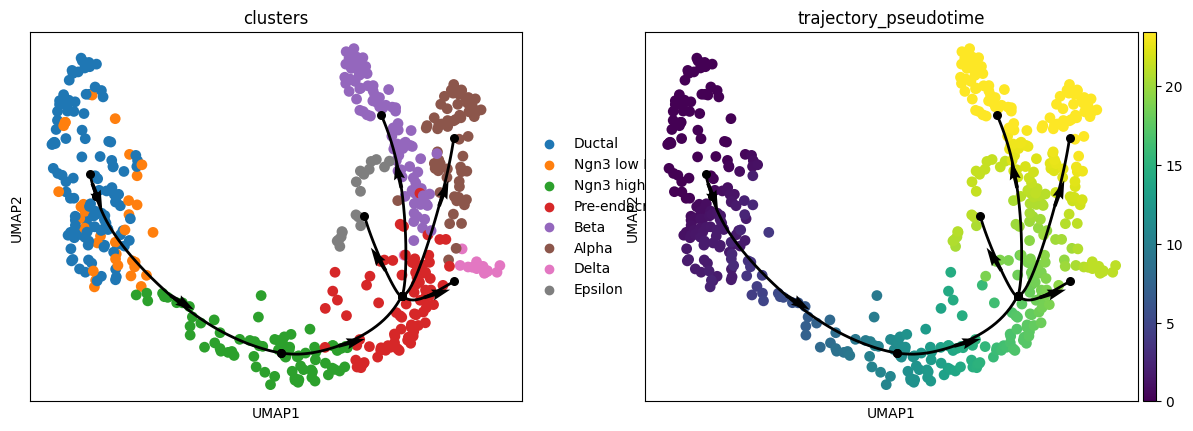

In [3]:
start_cell = "cell_000"
pseudotime_key = "trajectory_pseudotime"
fadata.obs[pseudotime_key] = fadata.get_trajectory_pseudotime(start_cell=start_cell)

cluster_key = "clusters"
cafe.plot.plot_trajectory(fadata, color=[cluster_key, pseudotime_key])

## 3. Method

In [4]:
# # common preprocessing
# import scvelo as scv

# scv.pp.filter_and_normalize(fadata, min_shared_counts=20, n_top_genes=2000)
# scv.pp.moments(fadata, n_pcs=20, n_neighbors=10)
# fadata

[09/08/2025 07:02:24] DEBUG    CondaBackend __init__                                                                                                                                                    
                      INFO     method_backend: CondaBackend: function_name-cf_comp1, load_backend-cfe                                                                                                   
                      DEBUG    Temp wd: /tmp/tmpskqw38z_                                                                                                                                                
                      INFO     cmd: conda run -n cfe --no-capture-output /usr/bin/time -v python /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/parse_args.py           
                               --function_name=cf_comp1 --adata_path=/tmp/tmpskqw38z_/adata.h5ad --prior_information=/tmp/tmpskqw38z_/prior_information.json                                        

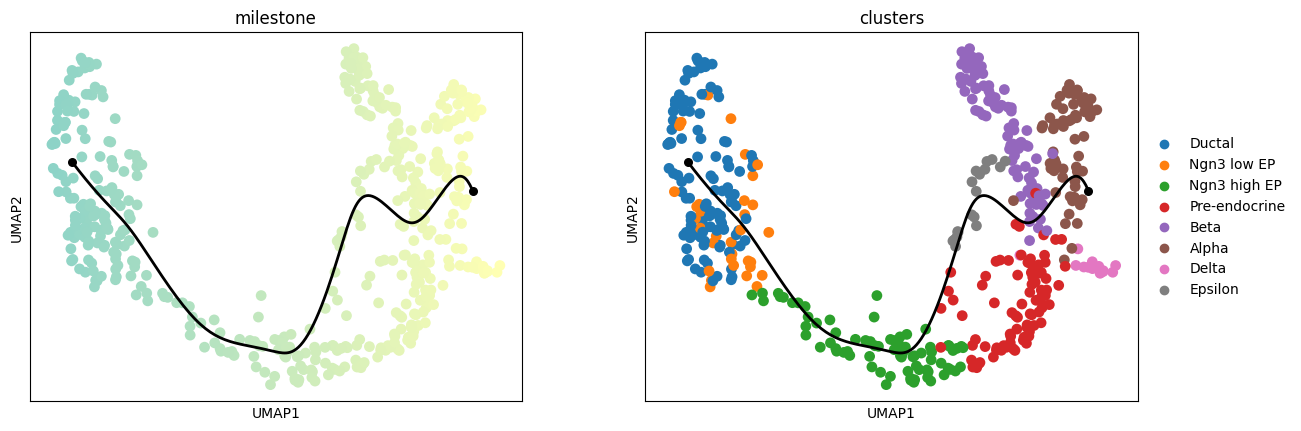

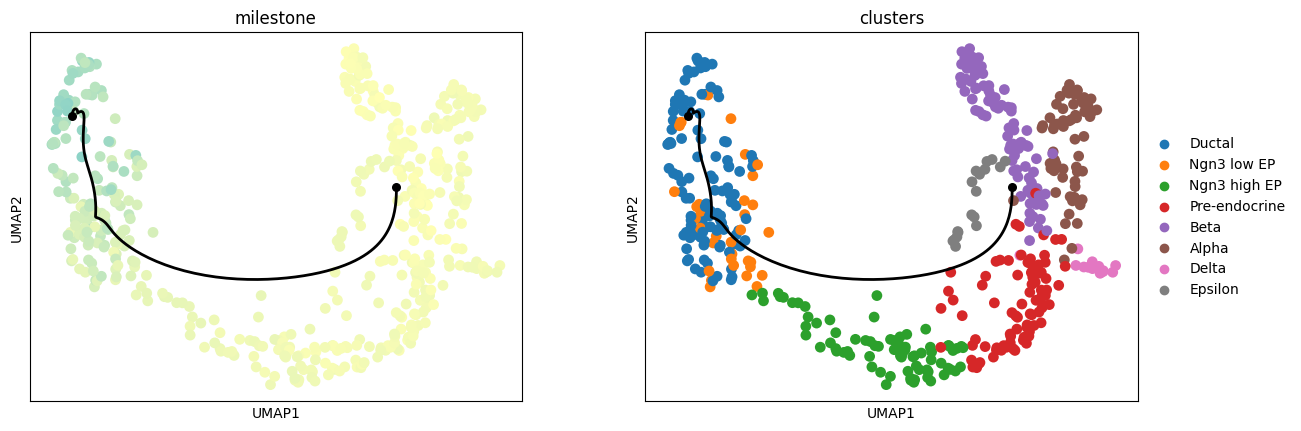

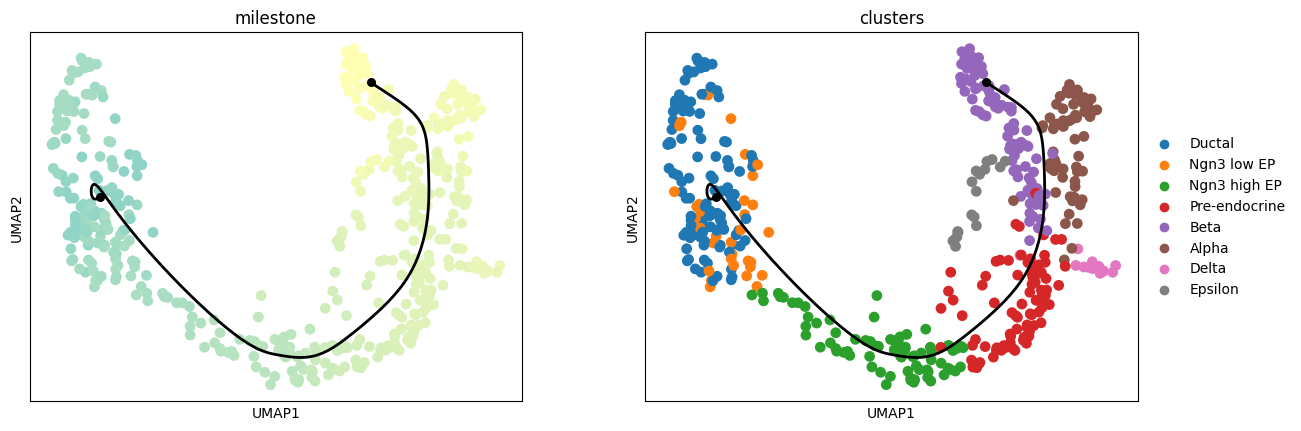

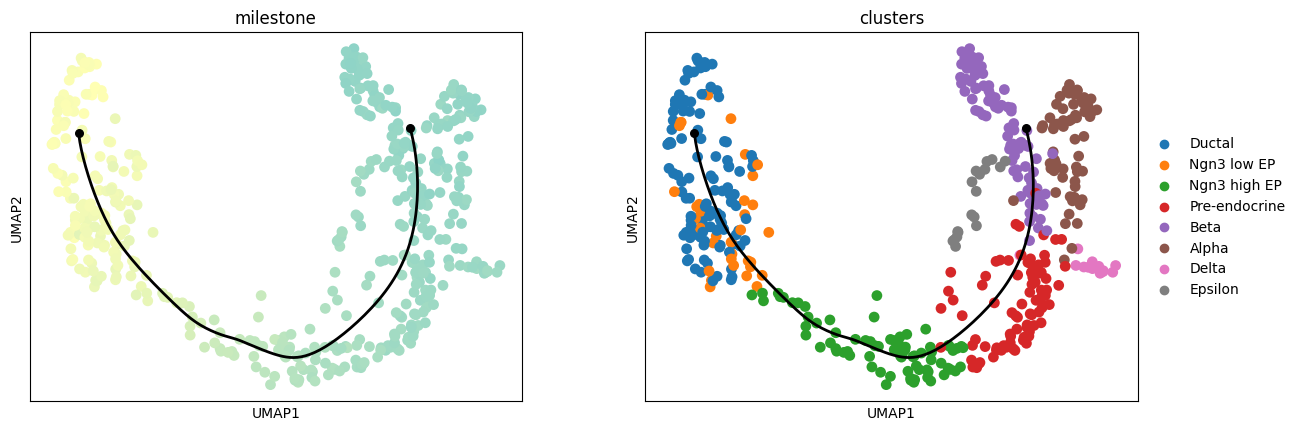

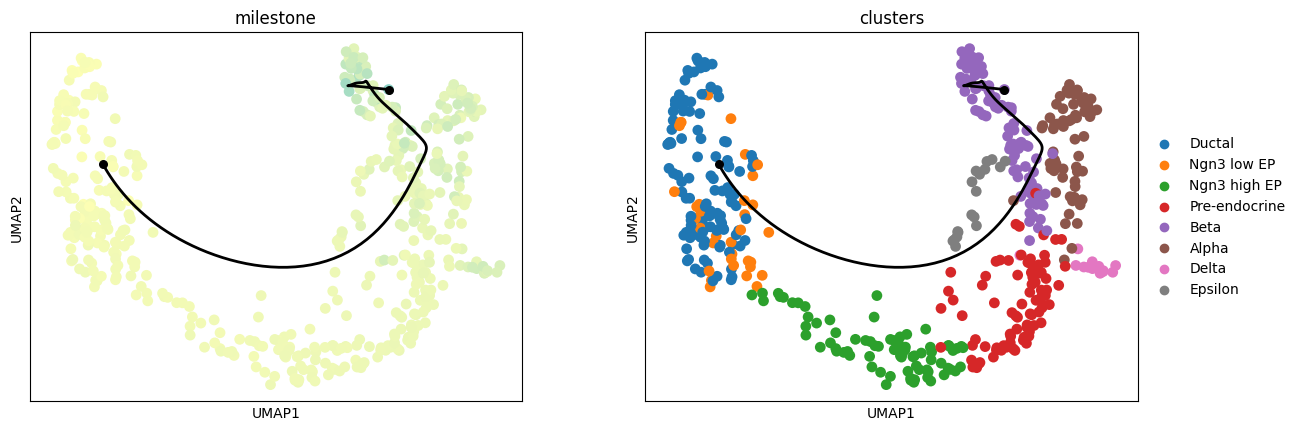

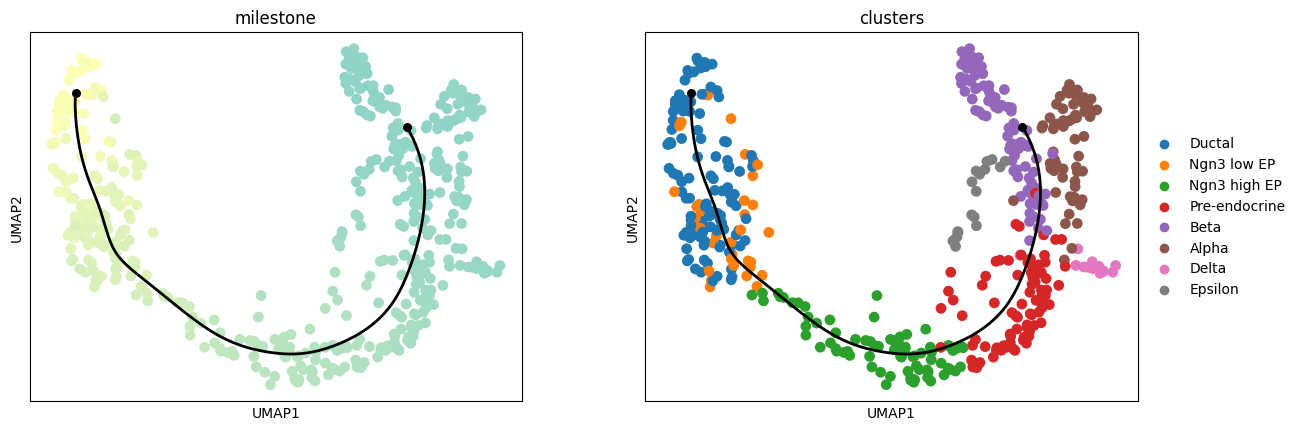

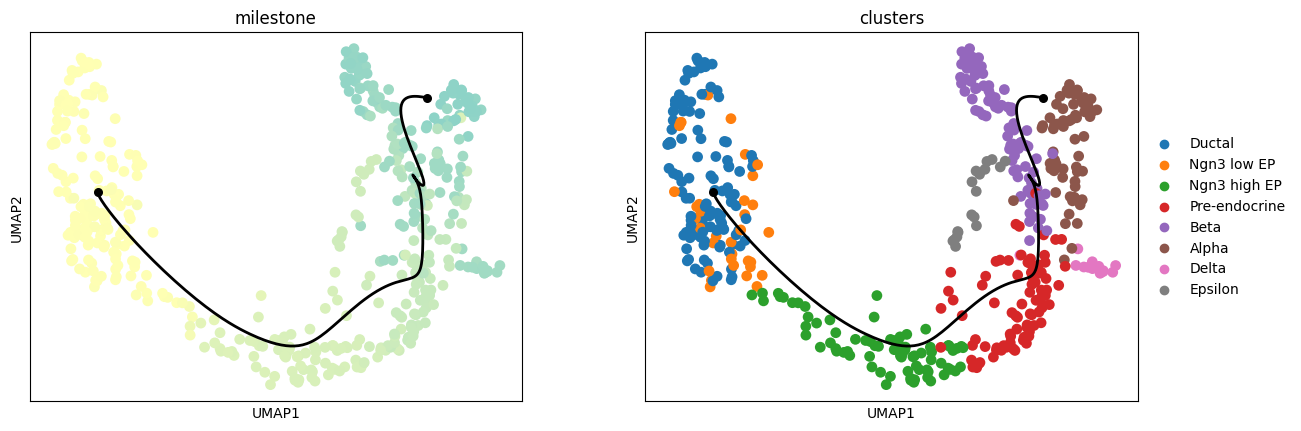

In [5]:
cluster_key = "clusters"
cluster_key_list = ["milestone", cluster_key]

method2parameters = {
    # new method 
    "comp1": {
        "basis": "X_umap",
    },
    "cytotrace2":{
        # TODO: parameters need adjust, cytotrace need 
        # TODO: cluster_key need to be extract from prior information
        "cluster_key": cluster_key,
        "cytotrace2_kwargs": {
            # "disable_parallelization": True, # 关闭并行
            "max_cores": 8, # 使用并行并指定核数, 当细胞数较少时，建议减少核数否则会阻塞在分数平滑处
        }
    },
    "palantir": {
        "palantir_results_kwargs": {
            "early_cell": "cell_000",
        },
    },
    "sctc": {},
    
    # old dynverse method
    "ti_comp1": {},
    "ti_scorpius":{},
    "ti_embeddr":{},
    # "ti_matcher":{},
    # "ti_tscan":{},
}

for method_name, parameters in method2parameters.items():
    parameters["repreprocess"] = True
    parameters["benchmark_resource"] = True  # record resource usage
    method = cafe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    cafe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)

Show model name

In [6]:
parsed_model_name_list = fadata.get_all_model_name() # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

[09/08/2025 07:04:47] WARNING  'ref' is not a valid random_time_string, don't need parse                                                                                                                


(['ref',
  'comp1-conda',
  'cytotrace2-conda',
  'palantir-conda',
  'sctc-conda',
  'ti_comp1-dynverse_docker',
  'ti_scorpius-dynverse_docker',
  'ti_embeddr-dynverse_docker'],
 ['ref',
  '20250908_190224__comp1-conda__JQNYzDztHp',
  '20250908_190228__cytotrace2-conda__FTOxnNGmnB',
  '20250908_190256__palantir-conda__6eWHMZYxDR',
  '20250908_190331__sctc-conda__C6r9rDrZ8G',
  '20250908_190336__ti_comp1-dynverse_docker__eBR9T4QUnV',
  '20250908_190414__ti_scorpius-dynverse_docker__2PNfDha74p',
  '20250908_190422__ti_embeddr-dynverse_docker__ueHcXWt9e6'])

## 4. Metric

In [7]:
# available metrics:
# cafe.metric.metrics

# metrics are chosen to be calculate
implemented = [
    # "edge_flip",
    "him",
    # "F1_branches",
    # "F1_milestones"
    # "correlation",
    # "rf_mse",
    # "rf_rsq",
    # "rf_nmse",
    # "lm_mse",
    # "lm_rsq",
    # "lm_nmse",
    # feature importance need to be fixed
    # "featureimp_cor", 
    # "featureimp_wcor",
    # "featureimp_ks",
    # "featureimp_wilcox",
    
]
# =========================================================================================================

# metric calculation
# extract all model names
models = fadata.trajectory_history_dict.keys()
fadata.update_uns_cfe() # update fadata.uns["cfe"]

# ensure waypoint wrapper for every model
for m in set(models) | {"ref"}:
    fadata.model_name = m
    if not fadata.is_wrapped_with_waypoints:
        fadata.add_waypoints()
        
# metric calculation and collect results
records = {}
for model in models:
    record = fadata.get_resource_usage(model) # extract resource usage
    if not (("angle" in model) or ("ref" in model)):
        # skip ref itself, skip ref angle (node loop may result in error)
        print(f"Calculating metrics for model: {model}")
        # metric calculation
        metric = cafe.metric.calculate_metrics(
            fadata,
            now_model=model,
            ref_model="ref",
            simplify=False, 
            metrics=implemented
        )
        # NOTE: add new psudotime correlation metric
        psudotime_corr = cafe.metric.calculate_pseudotime_correlation(
            fadata=fadata,
            # start_cell=start_cell,
            ref_start_milestone="Ductal",
            pred_start_milestone="milestone_begin",
            ref_model="ref",
            pred_model=model,
        )
        metric["psudotime_corr"] = psudotime_corr
        record.update(metric)
    records[model] = record
    

# metric dataframe
df = pd.DataFrame(records).T
styled_df = cafe.plot.style_benchmark(df)
df.to_csv("tmp/benchmark.csv")
styled_df

Calculating metrics for model: 20250908_190224__comp1-conda__JQNYzDztHp
                      DEBUG    find key:'pseudotime_from_Ductal' in trajectory dict, use it directly                                                                                                    
                      DEBUG    calculating new pseudotime                                                                                                                                               
                      DEBUG    save pseudotime to trajectory dict with key: `pseudotime_from_milestone_begin`                                                                                           
Calculating metrics for model: 20250908_190228__cytotrace2-conda__FTOxnNGmnB
                      DEBUG    find key:'pseudotime_from_Ductal' in trajectory dict, use it directly                                                                                                    
                      DEBUG    calculating new 

,time,memory,cpu,him,psudotime_corr
ref,nan,nan,nan,nan,nan
20250908_190224__comp1-conda__JQNYzDztHp,1.5700,649.1700,3.2700,0.2500,0.8709
20250908_190228__cytotrace2-conda__FTOxnNGmnB,24.7400,2095.1400,1.1100,0.2500,0.8229
20250908_190256__palantir-conda__6eWHMZYxDR,31.6100,1125.3700,18.1800,0.2500,0.9577
20250908_190331__sctc-conda__C6r9rDrZ8G,2.0600,712.8500,3.7400,0.2500,-0.9590
20250908_190336__ti_comp1-dynverse_docker__eBR9T4QUnV,-32.4689,379.7600,0.0000,0.2500,-0.9433
20250908_190414__ti_scorpius-dynverse_docker__2PNfDha74p,-2.8252,366.5100,0.0000,0.2500,-0.9753
20250908_190422__ti_embeddr-dynverse_docker__ueHcXWt9e6,-8.3651,841.4900,0.0000,0.2500,-0.9475


现有指标计算问题：

（1）计算太慢了（首要问题）

（2）大部分指标计算为空，feature相关指标报错